# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [2]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

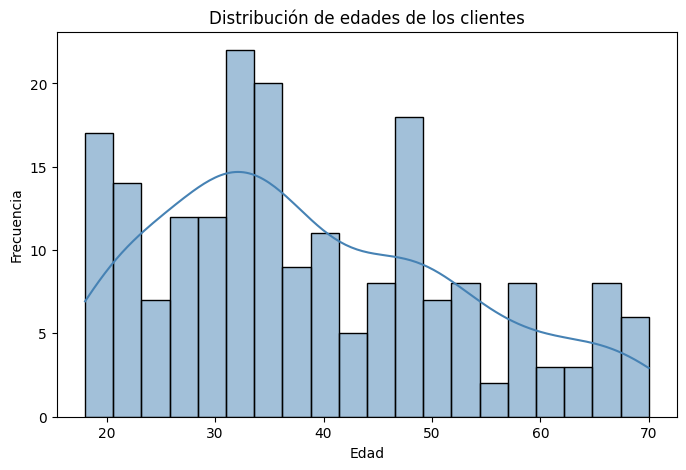

In [5]:
# cargar el dataset
df = pd.read_csv('data/retailmax.csv')

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', 
             bins=20,
             kde=True, 
             color='steelblue'
)

plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

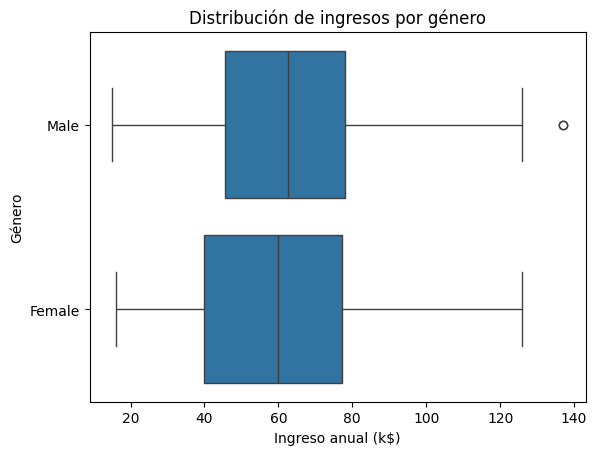

In [7]:
sns.boxplot(data=df,
            x='Annual Income (k$)',
            y='Gender'
)
plt.title('Distribución de ingresos por género')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Género')
plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

In [8]:
#primero debemos extrar la edad maxima y minima para crear los grupos de edad
age_min = df['Age'].min()
age_max = df['Age'].max()
print(f'Edad mínima: {age_min}, Edad máxima: {age_max}')

Edad mínima: 18, Edad máxima: 70


In [17]:
#segundo debemos crear los grupos de edad de 18 a 70 años, con intervalos de 25 años
bins = [18, 25, 50, 70]
labels = ['18-25', '26-50', '51-70']
df['Age Group'] = pd.cut(df['Age'], 
                         bins=bins, 
                         labels=labels,
                         include_lowest=True,
                            right=True
) 


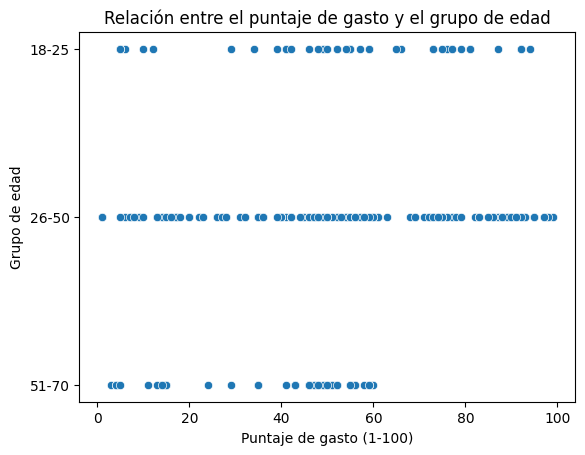

In [18]:
sns.scatterplot(data=df,
                x='Spending Score (1-100)',
                y='Age Group')

plt.title('Relación entre el puntaje de gasto y el grupo de edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Grupo de edad')
plt.show()

In [28]:
correlation = df ['Spending Score (1-100)'].corr(df['Age Group'].cat.codes)
print(f'Coeficiente de correlación de Pearson: {correlation:.2f}')

Coeficiente de correlación de Pearson: -0.21


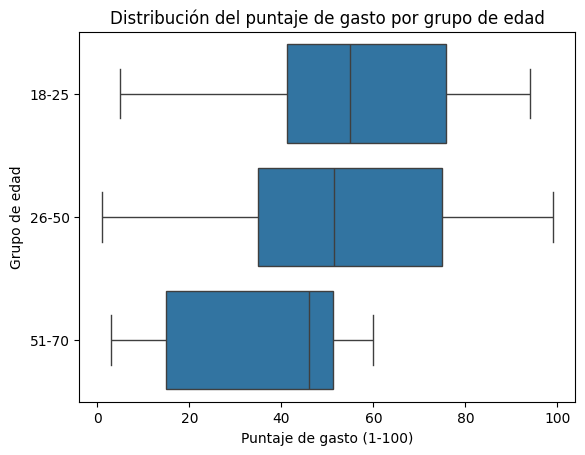

In [20]:
sns.boxplot(data=df,
            x='Spending Score (1-100)',
            y='Age Group'
)
plt.title('Distribución del puntaje de gasto por grupo de edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Grupo de edad')
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

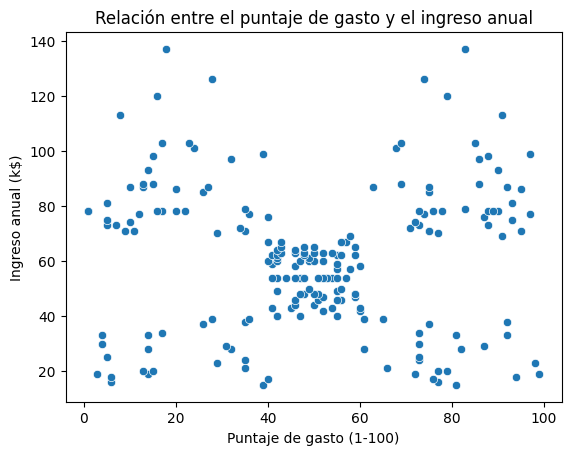

In [23]:
# primero identificamos si existe una relacion lineal entre el puntaje de gasto y el ingreo anual
sns.scatterplot(data=df,
                x='Spending Score (1-100)',
                y='Annual Income (k$)')
plt.title('Relación entre el puntaje de gasto y el ingreso anual')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Ingreso anual (k$)')
plt.show()

In [24]:
#Visualmente no parece existir una relacion lineal entre el puntaje de gasto y el ingreso anual, lo que sugiere que el comportamiento de gasto de los clientes no está directamente relacionado con su nivel de ingresos. Esto podría indicar que otros factores, como las preferencias personales, el estilo de vida o la situación económica, podrían estar influyendo en el puntaje de gasto de los clientes.
# Confirmamos con el coeficiente de correlación de Pearson
correlation = df['Spending Score (1-100)'].corr(df['Annual Income (k$)'])
print(f'Coeficiente de correlación de Pearson: {correlation:.2f}')

Coeficiente de correlación de Pearson: 0.01


### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

In [ ]:
#primero debesmos segmentar el ingreso anual en grupos.

income_bins = [0, 30, 60, 90, 120]
income_labels = ['0-30k$', '30-60k$', '60-90k$', '90-120k$']
df['Income Group'] = pd.cut(df['Annual Income (k$)'], 
                            bins=income_bins, 
                            labels=income_labels,
                            include_lowest=True,
                            right=True
)


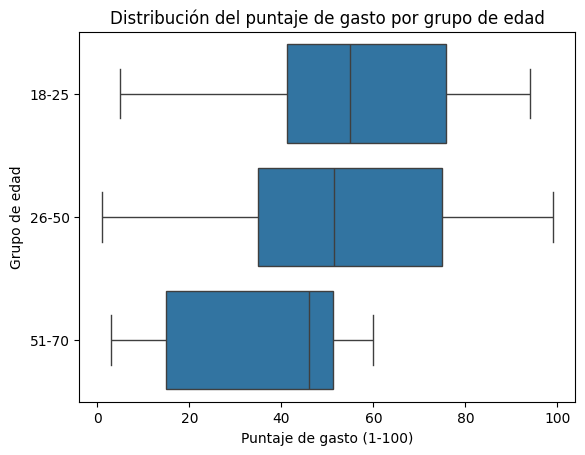

In [31]:
sns.boxplot(data=df,
            x='Spending Score (1-100)',
            y='Age Group'
)
plt.title('Distribución del puntaje de gasto por grupo de edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Grupo de edad')
plt.show()

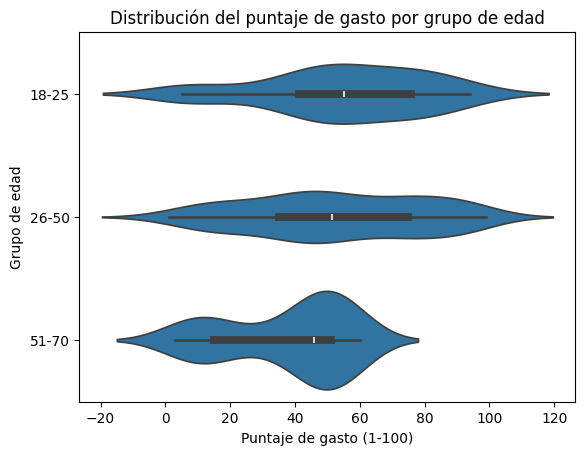

In [32]:
sns.violinplot(data=df,
                x='Spending Score (1-100)',
                y='Age Group'
)
plt.title('Distribución del puntaje de gasto por grupo de edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Grupo de edad')
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

In [36]:
#Primero hay que determinar cuantos hombres y mujeres hay en el dataset
gender_counts = df['Gender'].value_counts()
print (gender_counts)


Gender
Female    112
Male       88
Name: count, dtype: int64


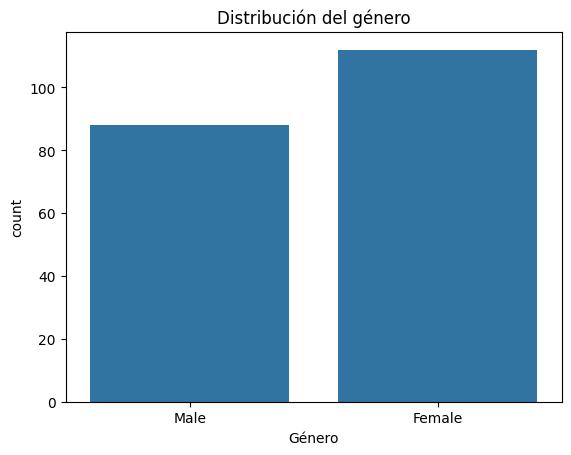

In [39]:
#ahora podemos visualizar la distribucion del puntaje de gasto por genero
sns.countplot(data=df,
              x='Gender'

)

plt.title('Distribución del género')
plt.xlabel('Género')
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

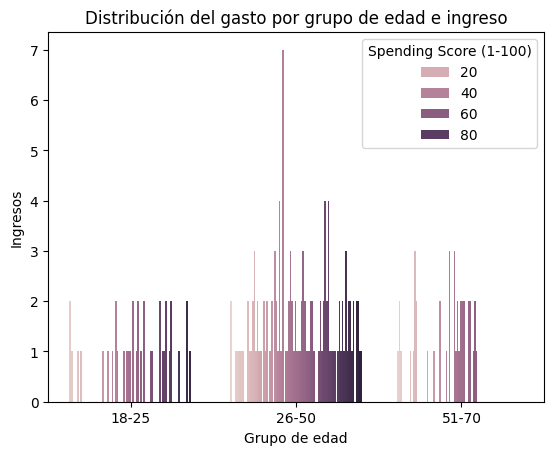

In [42]:
# el grupo que gasta más en promedio es de 18 a 25 años y de 30 a 60k$ de ingreso anual 
sns.countplot(data=df,
              x='Age Group',
              hue='Spending Score (1-100)'
)
plt.title('Distribución del gasto por grupo de edad e ingreso')
plt.xlabel('Grupo de edad')
plt.ylabel('Ingresos')
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

In [ ]:
#ingreso promedio por edad como complemento 
income_by_age = df.groupby('Age Group')['Annual Income (k$)'].mean()
print(income_by_age)

Age Group
18-25    45.684211
26-50    67.393443
51-70    53.850000
Name: Annual Income (k$), dtype: float64


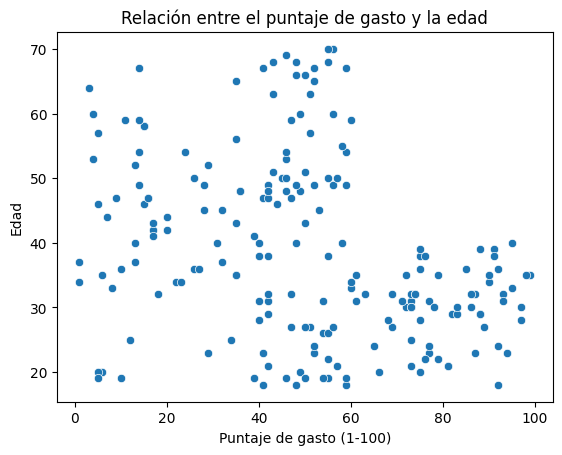

In [44]:
sns.scatterplot(data=df,
                x='Spending Score (1-100)',
                y='Age'
)
plt.title('Relación entre el puntaje de gasto y la edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Edad')
plt.show()

In [47]:
#por último podemos visualizar correlación de pearson entre el puntaje de gasto y la edad
correlation = df['Age'].corr(df['Spending Score (1-100)'])
print(f'Coeficiente de correlación de Pearson: {correlation:.2f}')

Coeficiente de correlación de Pearson: -0.33


### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

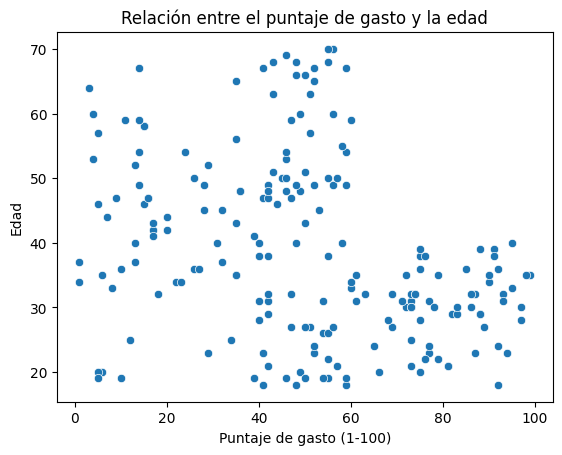

In [48]:
sns.scatterplot(data=df,
                x='Spending Score (1-100)',
                y='Age'
)
plt.title('Relación entre el puntaje de gasto y la edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Edad')
plt.show()

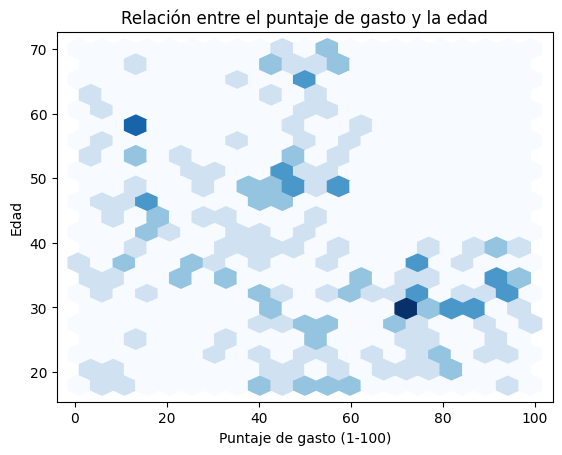

In [51]:
plt.hexbin(x=df['Spending Score (1-100)'],
           y=df['Age'],
           gridsize=20,
           cmap='Blues'
)
plt.title('Relación entre el puntaje de gasto y la edad')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Edad')
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

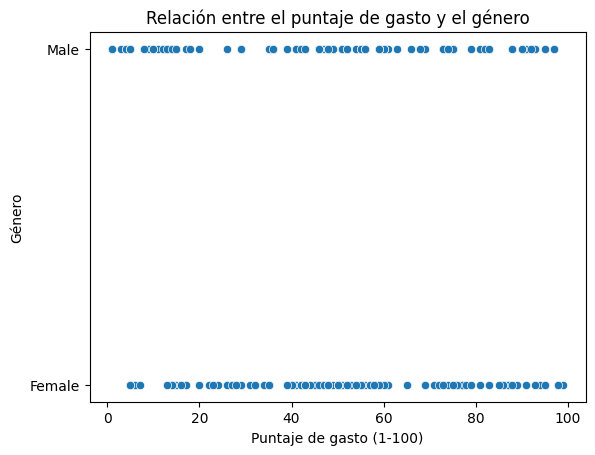

In [52]:
sns.scatterplot(data=df,
                x='Spending Score (1-100)',
                y='Gender'
)
plt.title('Relación entre el puntaje de gasto y el género')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Género')
plt.show()  

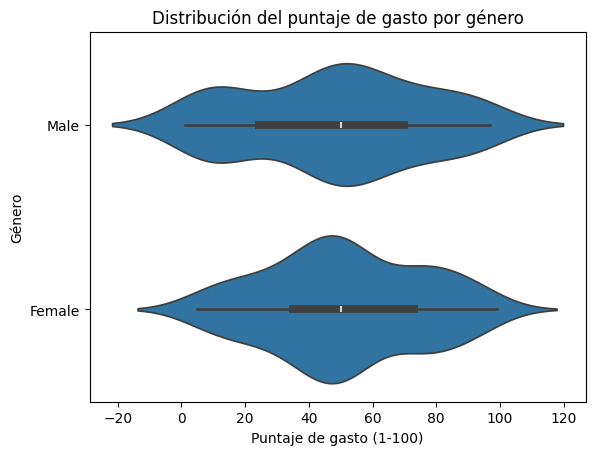

In [53]:
sns.violinplot(data=df,
               x='Spending Score (1-100)', 
                y='Gender'
)
plt.title('Distribución del puntaje de gasto por género')
plt.xlabel('Puntaje de gasto (1-100)')
plt.ylabel('Género')
plt.show()